# End-of-unit project — Evaluating a cancer screening classifier

**Chapter 5 · Unit 3 — Application of Supervised Learning for Classification**

> **Student worksheet.** Yellow *Question* boxes are for you to answer in your own words — discuss with a classmate or your instructor. Green *Try it yourself* exercises are open-ended hands-on tasks. The matching instructor notebook contains worked solutions and answers.

## The story

A clinic is screening patients for breast cancer using a digital image of a tumor's cell nuclei. They have a logistic regression model that, given 30 image-derived measurements, outputs a probability that the tumor is malignant. The clinic's medical director hands you the model and asks: **"Is this good enough to use?"**

This is a different question from the ones we've been answering so far. We've spent the last two units asking *"How do we build a model?"* — choosing features, fitting algorithms, tuning hyperparameters. This project asks the harder question: **"How do we know whether a model is any good?"** And specifically — for a *cancer screening* context, where the cost of missing a real case is far greater than the cost of a false alarm.

We'll use the same **Breast Cancer Wisconsin** dataset you saw in Unit 1, but with a completely different focus. Where Unit 1 asked you to train a Decision Tree, this project will train a logistic regression in 3 lines and then spend the rest of the notebook scrutinizing the result.

## What you'll do

1. Train a logistic regression classifier (3 lines)
2. Build a **confusion matrix** and read it as a clinician would
3. Compute and interpret **accuracy, precision, recall, specificity, F1**
4. See *why accuracy alone lies* in medical screening
5. Tune the **decision threshold** to control the precision/recall tradeoff
6. Build the **ROC curve** and compute the **AUC**
7. Compare logistic regression to a Decision Tree using ROC
8. Find the threshold that minimizes the **real-world cost** of mistakes

Color key:

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 8px 12px; margin: 4px 0;"><strong>Question for you</strong> — short conceptual questions.</div>
<div style="background-color: #ede9fe; border-left: 4px solid #7c3aed; padding: 8px 12px; margin: 4px 0;"><strong>Answer</strong> — solutions appear in the instructor notebook.</div>
<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 8px 12px; margin: 4px 0;"><strong>Tip</strong> — useful clarifications.</div>
<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 8px 12px; margin: 4px 0;"><strong>Watch out</strong> — common mistakes to avoid.</div>
<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 8px 12px; margin: 4px 0;"><strong>Try it yourself</strong> — extended hands-on exercises with worked solutions.</div>


## 0. Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets         import load_breast_cancer
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.metrics          import (accuracy_score, confusion_matrix, classification_report,
                                      precision_score, recall_score, f1_score,
                                      roc_curve, roc_auc_score, precision_recall_curve)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Color palette consistent with previous notebooks
MALIGNANT = "#D85A30"   # the class we want to detect
BENIGN    = "#1D9E75"

RANDOM_STATE = 42

## 1. Load and recode the target

The `load_breast_cancer` dataset comes pre-cleaned and ready to use. But there's one thing to fix.

In [8]:
data = load_breast_cancer()
print(f"Class labels:  {dict(enumerate(data.target_names))}")
print(f"Class counts:  {dict(zip(data.target_names, np.bincount(data.target)))}")

Class labels:  {0: 'malignant', 1: 'benign'}
Class counts:  {'malignant': 212, 'benign': 357}


<div style="background-color: #fee2e2; border-left: 4px solid #ef4444; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Watch out</strong><br>scikit-learn labels this dataset <strong>backwards</strong> from medical convention. It uses <code>0 = malignant</code> and <code>1 = benign</code>, but in clinical work the <em>positive</em> class is always 'has the disease'. Without fixing this, <code>recall</code> would mean 'fraction of benign tumors correctly identified' — the opposite of what a clinician calls sensitivity.<br><br>We flip the labels so that <strong>1 = malignant (positive)</strong> and <strong>0 = benign (negative)</strong>. From now on, every metric reads the way a clinician expects.</div>

In [10]:
# Flip 0 and 1 so 1 = malignant (positive class)
X = data.data
y = 1 - data.target

print(f"After flipping:")
print(f"  malignant (1): {sum(y == 1)}")
print(f"  benign    (0): {sum(y == 0)}")
print(f"  malignant rate: {y.mean():.3f}")

After flipping:
  malignant (1): 212
  benign    (0): 357
  malignant rate: 0.373


## 2. Train a logistic regression

We'll train a baseline classifier in five lines and spend the rest of the notebook examining what it does.

In [12]:
# Stratified split — preserves the malignant rate in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE,
)

# Train logistic regression. We use 'liblinear' 
# and a high max_iter to ensure clean convergence on this 30-feature dataset.
lr = LogisticRegression(solver="liblinear", max_iter=10000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 426 samples
Test set:     143 samples


## 3. First look at performance — the seductive single number

In [14]:
y_pred = lr.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test accuracy: 0.9441


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br><strong>94% accuracy</strong>. Sounds great. But before celebrating, two questions:<br>(a) What does '94% accuracy' actually <em>mean</em> in this medical context?<br>(b) If you were the clinic's medical director, would you ship this model based on this number alone?</div>

## 4. The confusion matrix — what kinds of mistakes did we make?

[[89  1]
 [ 7 46]]


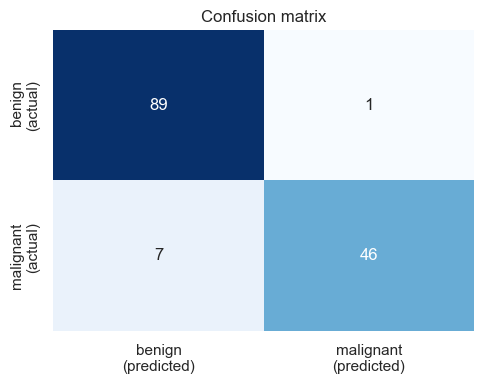

In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

# A nicer plot
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["benign\n(predicted)", "malignant\n(predicted)"],
            yticklabels=["benign\n(actual)",   "malignant\n(actual)"],
            ax=ax)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br>Reading the confusion matrix:<ul style='margin:6px 0;'><li><strong>Top-left</strong> (89): <em>True Negatives</em> — benign tumors correctly identified as benign.</li><li><strong>Top-right</strong> (1): <em>False Positives</em> — benign tumors that the model alarmed about. The patient gets called back for an unnecessary biopsy.</li><li><strong>Bottom-left</strong> (7): <em>False Negatives</em> — <strong>missed cancers</strong>. The patient is told they're fine when they're not.</li><li><strong>Bottom-right</strong> (46): <em>True Positives</em> — malignant tumors correctly flagged.</li></ul>Of the four cells, the bottom-left is the one that should make you uncomfortable.</div>

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>We had 53 actual cancer patients in the test set. The model correctly identified 46 of them. <strong>What about the other 7?</strong> What happens to those patients in the real world?</div>

## 5. The four metrics that actually matter

The slides defined precision, recall (= sensitivity), specificity, and F1. Let's compute them and see what each one tells us.

In [21]:
tn, fp, fn, tp = cm.ravel()

accuracy    = (tp + tn) / (tp + tn + fp + fn)
precision   = tp / (tp + fp)              # of those we said are malignant, how many are?
recall      = tp / (tp + fn)              # of all malignant, how many did we catch? (= sensitivity)
specificity = tn / (tn + fp)              # of all benign, how many did we correctly clear?
f1          = 2 * precision * recall / (precision + recall)

print(f"Accuracy    = {accuracy:.3f}    (overall correctness)")
print(f"Precision   = {precision:.3f}   (of malignant predictions, how many were right?)")
print(f"Recall      = {recall:.3f}      (of real cancers, how many did we catch?)")
print(f"Specificity = {specificity:.3f} (of benign tumors, how many cleared correctly?)")
print(f"F1 score    = {f1:.3f}          (harmonic mean of precision and recall)")

Accuracy    = 0.944    (overall correctness)
Precision   = 0.979   (of malignant predictions, how many were right?)
Recall      = 0.868      (of real cancers, how many did we catch?)
Specificity = 0.989 (of benign tumors, how many cleared correctly?)
F1 score    = 0.920          (harmonic mean of precision and recall)


In [22]:
# scikit-learn's classification_report computes these in one shot
print(classification_report(y_test, y_pred,
                            target_names=["benign", "malignant"], digits=3))

              precision    recall  f1-score   support

      benign      0.927     0.989     0.957        90
   malignant      0.979     0.868     0.920        53

    accuracy                          0.944       143
   macro avg      0.953     0.928     0.938       143
weighted avg      0.946     0.944     0.943       143



<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>The model has <strong>precision = 0.979</strong> for malignant — but <strong>recall = 0.868</strong>. Why is the gap there, and which of these two should the clinic care more about? Is there any setting where you'd care more about precision?</div>

## 6. The "accuracy alone is misleading" trap


In [25]:
# Build a "model" that does no learning — it just predicts "benign" for everyone
y_pred_naive = np.zeros_like(y_test)   # all zeros = all benign

acc_naive = accuracy_score(y_test, y_pred_naive)
recall_naive = recall_score(y_test, y_pred_naive, zero_division=0)

print(f"Naive 'always-benign' classifier:")
print(f"  accuracy = {acc_naive:.4f}")
print(f"  recall   = {recall_naive:.4f}")

Naive 'always-benign' classifier:
  accuracy = 0.6294
  recall   = 0.0000


<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>A model that does <strong>literally no learning</strong> — just always says 'benign' — achieves <strong>63% accuracy</strong> on this dataset. That's because 63% of the test set really is benign.<br><br>Compared to our trained model's 94% accuracy, the naive model is much worse. But what about <strong>recall</strong>? And what does this tell you about reading accuracy numbers in general?</div>

## 7. The decision threshold — a knob you can turn

So far we've been using `lr.predict()`, which makes hard 0/1 predictions using a default threshold of **0.5**: anything with predicted probability ≥ 0.5 is classified as malignant.

But that 0.5 isn't sacred. It's a default. We can pick any threshold we want — and different thresholds give different precision/recall tradeoffs.

In [28]:
# Get the predicted probabilities of being malignant (class 1)
y_prob = lr.predict_proba(X_test)[:, 1]

# Show a few examples
print("Examples of predicted probabilities:")
for i in [0, 5, 10, 50, 100]:
    actual = "malignant" if y_test[i] == 1 else "benign"
    print(f"  Patient {i:3d}: P(malignant) = {y_prob[i]:.4f}    (actual: {actual})")

Examples of predicted probabilities:
  Patient   0: P(malignant) = 1.0000    (actual: malignant)
  Patient   5: P(malignant) = 0.0043    (actual: benign)
  Patient  10: P(malignant) = 0.9804    (actual: malignant)
  Patient  50: P(malignant) = 0.1671    (actual: malignant)
  Patient 100: P(malignant) = 0.0078    (actual: benign)


<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br><code>lr.predict_proba(X)[:, 1]</code> returns the model's <em>continuous score</em> for each patient — the probability it assigns to the malignant class. This is the 'soft classifier'. <code>lr.predict(X)</code> is the 'crisp' version: it just thresholds these probabilities at 0.5. Probabilities give you so much more — they tell you <em>how confident</em> the model is, not just what it decided.</div>

### 7.1 — Sweep the threshold and watch the metrics move

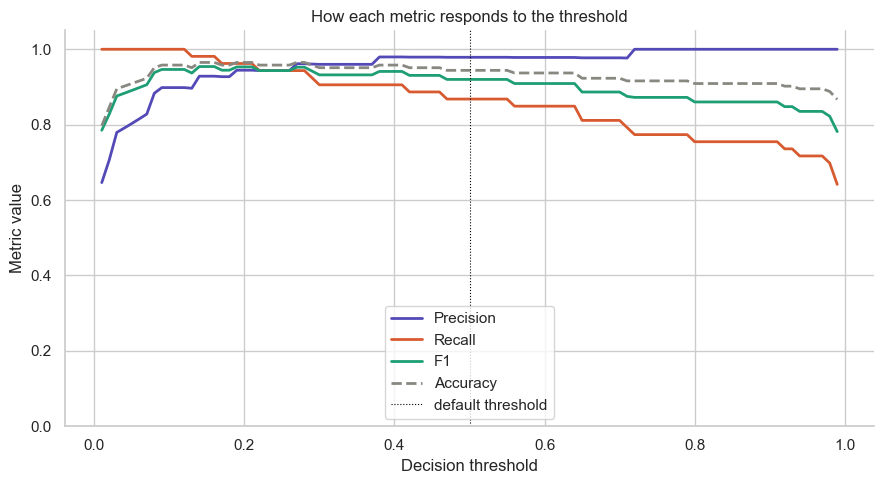

In [31]:
thresholds = np.linspace(0.01, 0.99, 99)
precisions, recalls, f1s, accuracies = [], [], [], []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    accuracies.append(accuracy_score(y_test, y_pred_t))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, label="Precision",   color="#534AB7", linewidth=2)
ax.plot(thresholds, recalls,    label="Recall",      color="#D85A30", linewidth=2)
ax.plot(thresholds, f1s,        label="F1",          color="#1D9E75", linewidth=2)
ax.plot(thresholds, accuracies, label="Accuracy",    color="#888780", linewidth=2, linestyle="--")
ax.axvline(0.5, color="black", linewidth=0.8, linestyle=":", label="default threshold")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("How each metric responds to the threshold")
ax.legend(loc="lower center")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Look at the curves carefully:<br>(a) As the threshold drops below 0.5, what happens to recall, and why?<br>(b) As the threshold rises above 0.5, what happens to precision, and why?<br>(c) The clinic's medical director tells you 'we cannot accept missing more than 2% of cancers'. Which threshold should you set?</div>

## 8. ROC curve and AUC — the threshold-free view

The threshold-tuning plot showed how different choices of threshold trade precision against recall. **The ROC curve** is the same idea, plotted in a more standard way that lets you compare models directly.

The ROC plots:
- **x-axis**: False Positive Rate (FPR) = `1 − specificity` — fraction of benign tumors falsely flagged
- **y-axis**: True Positive Rate (TPR) = `recall` = `sensitivity` — fraction of real cancers caught

Each point on the curve represents a different threshold. The curve is generated by sweeping the threshold from 0 to 1.

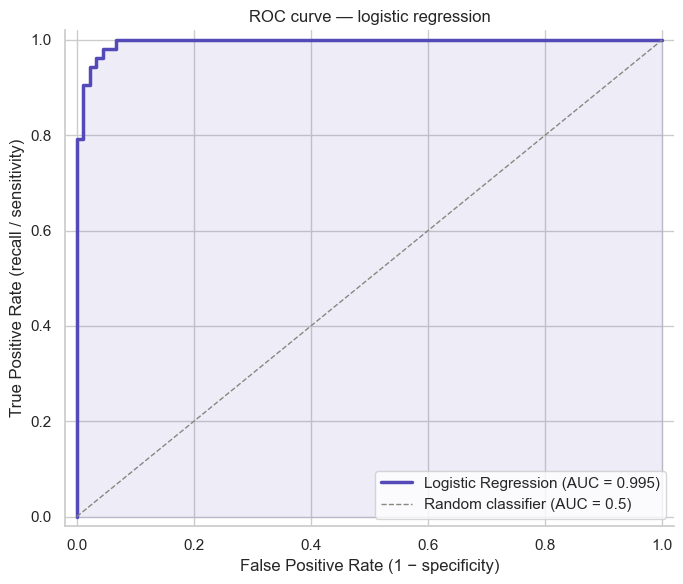

AUC: 0.9952


In [34]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#534AB7", linewidth=2.5,
        label=f"Logistic Regression (AUC = {auc_value:.3f})")
ax.plot([0, 1], [0, 1], color="#888780", linewidth=1, linestyle="--",
        label="Random classifier (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.1, color="#534AB7")
ax.set_xlabel("False Positive Rate (1 − specificity)")
ax.set_ylabel("True Positive Rate (recall / sensitivity)")
ax.set_title("ROC curve — logistic regression")
ax.legend(loc="lower right")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_value:.4f}")

<div style="background-color: #dbeafe; border-left: 4px solid #3b82f6; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Tip</strong><br><strong>Reading the ROC curve.</strong> The dashed diagonal is what a coin-flip classifier would give you: every gain in recall is paid for by an equal increase in false positives. Any classifier that bows above the diagonal is doing better than chance. The closer to the <strong>top-left corner</strong> the curve gets, the better — that's where recall is high and false positive rate is low simultaneously. A perfect classifier would go straight up the y-axis and across the top, with AUC = 1.0.</div>

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>(a) Our logistic regression has <strong>AUC = 0.995</strong>. What does that number actually <em>mean</em>? Try to explain it without the words 'area' or 'curve'.<br>(b) Is it possible for one model to have <em>higher accuracy</em> than another but <em>lower AUC</em>? Or vice versa?</div>

### 8.1 — Comparing models on the same ROC plot

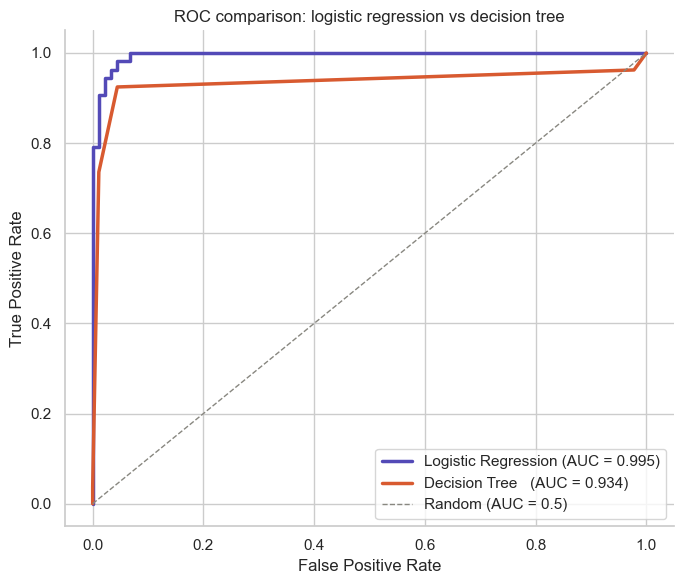

In [38]:
# Train a Decision Tree for comparison
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr,    tpr,    color="#534AB7", linewidth=2.5,
        label=f"Logistic Regression (AUC = {auc_value:.3f})")
ax.plot(fpr_dt, tpr_dt, color="#D85A30", linewidth=2.5,
        label=f"Decision Tree   (AUC = {auc_dt:.3f})")
ax.plot([0, 1], [0, 1], color="#888780", linewidth=1, linestyle="--",
        label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC comparison: logistic regression vs decision tree")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

<div style="background-color: #fef3c7; border-left: 4px solid #f59e0b; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Question for you</strong><br>Which model would you ship for screening?</div>

## 9. Stretch exercises (with solutions)


<div style="background-color: #dcfce7; border-left: 4px solid #16a34a; padding: 12px 16px; border-radius: 4px; margin: 16px 0;"><strong>Try it yourself</strong><br><strong>1. The cost-minimizing threshold.</strong><br>A health economics study estimates that a missed cancer (false negative) costs the system about <strong>\$10,000</strong> in delayed treatment and worse outcomes, while a false alarm (false positive) costs about <strong>$1,000</strong> in unnecessary biopsy and patient anxiety. Assume the standard 10:1 cost ratio.<br><br>Find the threshold that minimizes <strong>total cost</strong> on the test set. Compare it to the default threshold of 0.5 — how different is it, and how much money does the better threshold save?</div>

Default threshold (0.50):       cost =  71  (FN=7, FP=1)
Cost-minimizing threshold (0.09): cost =   6  (FN=0, FP=6)
Savings vs default: 65 units (~$65,000)


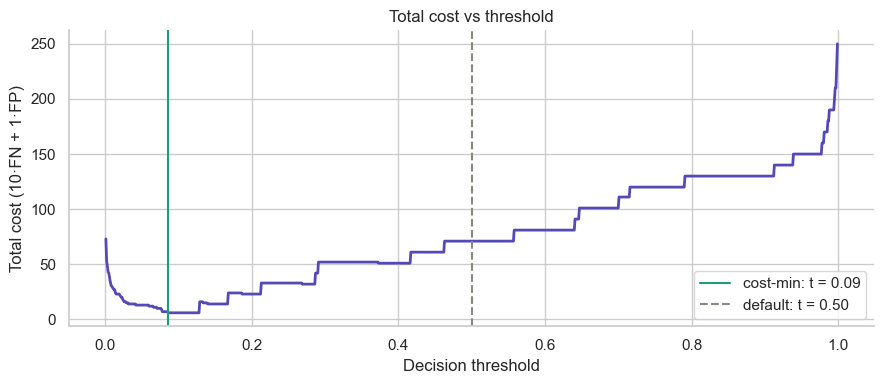

In [42]:
# Cost: 10 per false negative, 1 per false positive (in arbitrary units of $1k)
COST_FN = 10
COST_FP = 1

thresholds = np.linspace(0.001, 0.999, 999)
total_cost = []
n_fn_list, n_fp_list = [], []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()
    total_cost.append(COST_FN * fn + COST_FP * fp)
    n_fn_list.append(fn)
    n_fp_list.append(fp)

total_cost = np.array(total_cost)
best_idx = total_cost.argmin()
best_threshold = thresholds[best_idx]
best_cost = total_cost[best_idx]

# Compare to default threshold 0.5
default_idx = np.abs(thresholds - 0.5).argmin()
default_cost = total_cost[default_idx]

print(f"Default threshold (0.50):       cost = {default_cost:>3.0f}  "
      f"(FN={n_fn_list[default_idx]}, FP={n_fp_list[default_idx]})")
print(f"Cost-minimizing threshold ({best_threshold:.2f}): cost = {best_cost:>3.0f}  "
      f"(FN={n_fn_list[best_idx]}, FP={n_fp_list[best_idx]})")
print(f"Savings vs default: {default_cost - best_cost:.0f} units (~${(default_cost - best_cost) * 1000:,.0f})")

# Plot cost vs threshold
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, total_cost, color="#534AB7", linewidth=2)
ax.axvline(best_threshold, color="#1D9E75", linewidth=1.5,
           label=f"cost-min: t = {best_threshold:.2f}")
ax.axvline(0.5, color="#888780", linewidth=1.5, linestyle="--",
           label="default: t = 0.50")
ax.set_xlabel("Decision threshold")
ax.set_ylabel(f"Total cost ({COST_FN}·FN + {COST_FP}·FP)")
ax.set_title("Total cost vs threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Recap

You exercised the full evaluation toolkit for classification:

| Concept | What it tells you | Tool |
|---|---|---|
| Confusion matrix | Which kinds of mistakes the model makes | `confusion_matrix` |
| Accuracy | Overall correctness — but only meaningful when classes are balanced | `accuracy_score` |
| Precision | Of positive predictions, how many are real | `precision_score` |
| Recall (sensitivity) | Of real positives, how many we caught | `recall_score` |
| Specificity | Of real negatives, how many we cleared | `1 − FPR` |
| F1 | Harmonic mean of precision and recall — single number when both matter | `f1_score` |
| Threshold tuning | Trade precision for recall by adjusting the cutoff | `predict_proba` + threshold |
| ROC curve | All threshold choices visualized | `roc_curve` |
| AUC | Threshold-free model quality; rank-ordering ability | `roc_auc_score` |
| Cost analysis | The threshold that minimizes real-world harm | (manual loop) |

### The two big takeaways

1. **Accuracy is a starting point, not the whole story.** In any imbalanced or asymmetric-cost problem, accuracy can hide everything important. Always inspect the confusion matrix and the per-class metrics.

2. **The default threshold is rarely the right threshold.** The decision threshold is a *business* knob, not a *technical* one. It encodes how much you weigh false negatives against false positives, and only a domain expert can tell you what that weight should be.

### Where to go next

The next units (Decision Tree, KNN, SVM, Ensembles) introduce more powerful classifiers — but the evaluation toolkit you built in this project applies to <em>all</em> of them. Whatever model you train in chapters to come, the same questions matter: what's the confusion matrix? Where does the AUC sit? What threshold makes sense for the application? You now have the vocabulary to ask those questions about any classifier you encounter.
